In [61]:
%pip install pandas imblearn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, recall_score, precision_score, f1_score
)

import joblib

In [63]:
DATASET_PATH = '../data/'

In [64]:
files = [file for file in os.listdir(DATASET_PATH) if file.endswith('.csv')]


In [65]:
df_test_0 = pd.read_csv(os.path.join(DATASET_PATH, files[0]))
df_test_0.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [66]:
df_test_1 = pd.read_csv(os.path.join(DATASET_PATH, files[1]))
df_test_1.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [67]:
df_list = []

for file in files:
    df = pd.read_csv(os.path.join(DATASET_PATH, file), encoding='cp1252')
    df_list.append(df)

df = pd.concat(df_list)
print(f"Total rows: {len(df)}")

Total rows: 2830743


In [68]:
print(df.columns)

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [69]:
# Strip whitespace from column names
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [70]:
# thay thế inf, -inf với NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Lấy ra tất cả cột số
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(numeric_cols)

# Thay thế NaN bằng median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [71]:
# zero-variance columns
zero_var_cols = df.columns[df.nunique() == 1]
print(zero_var_cols)

# test
print(df[zero_var_cols[0]])

# drop 
df.drop(columns=zero_var_cols, inplace=True)

Index(['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk',
       'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk',
       'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate'],
      dtype='object')
0         0
1         0
2         0
3         0
4         0
         ..
692698    0
692699    0
692700    0
692701    0
692702    0
Name: Bwd PSH Flags, Length: 2830743, dtype: int64


In [72]:
# Drop duplicate rows
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicate rows: 308381


In [73]:
print(df.dtypes)

Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                           object
Length: 71, dtype: object


In [74]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 2522362 entries, 0 to 692702
Data columns (total 71 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  Flow I

In [75]:
FLOAT_COLUMNS = {
    # Flow statistics
    'Flow Bytes/s', 'Flow Packets/s',
    'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
    # Packet length statistics
    'Fwd Packet Length Mean', 'Fwd Packet Length Std',
    'Bwd Packet Length Mean', 'Bwd Packet Length Std',
    'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
    # Segment averages
    'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
    # IAT
    'Fwd IAT Mean', 'Fwd IAT Std', 'Bwd IAT Mean', 'Bwd IAT Std',
    # Activity
    'Active Mean', 'Active Std', 'Active Max', 'Active Min',
    'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min',
}
def optimize_dtypes(df):
    # Bước 1: Ép tất cả cột float thành float32 TRƯỚC
    for col in df.columns:
        if col in FLOAT_COLUMNS:
            df[col] = df[col].astype(np.float32)
    
    # Bước 2: Downcast int cho các cột còn lại
    int_cols = df.select_dtypes(include=['int64', 'int32', 'int16', 'int8']).columns
    for col in int_cols:
        c_min = df[col].min()
        c_max = df[col].max()
        
        if c_min >= 0:
            if c_max <= np.iinfo(np.uint8).max:
                df[col] = df[col].astype(np.uint8)
            elif c_max <= np.iinfo(np.uint16).max:
                df[col] = df[col].astype(np.uint16)
            elif c_max <= np.iinfo(np.uint32).max:
                df[col] = df[col].astype(np.uint32)
        else:
            if np.iinfo(np.int8).min <= c_min and c_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif np.iinfo(np.int16).min <= c_min and c_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif np.iinfo(np.int32).min <= c_min and c_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
            # else: giữ nguyên int64
    
    # Ép IAT Total/Max (thời gian) thành float32
    iat_cols = ['Fwd IAT Total', 'Fwd IAT Max', 'Bwd IAT Total', 'Bwd IAT Max']
    for col in iat_cols:
        if col in df.columns:
            df[col] = df[col].astype(np.float32)
    # Ép rate columns (Packets/s) thành float32 thay vì float64
    rate_cols = ['Fwd Packets/s', 'Bwd Packets/s']
    for col in rate_cols:
        if col in df.columns:
            df[col] = df[col].astype(np.float32)
    return df
df = optimize_dtypes(df)

In [76]:
print(df.info(memory_usage='deep'))

<class 'pandas.core.frame.DataFrame'>
Index: 2522362 entries, 0 to 692702
Data columns (total 71 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             uint16 
 1   Flow Duration                int32  
 2   Total Fwd Packets            uint32 
 3   Total Backward Packets       uint32 
 4   Total Length of Fwd Packets  uint32 
 5   Total Length of Bwd Packets  uint32 
 6   Fwd Packet Length Max        uint16 
 7   Fwd Packet Length Min        uint16 
 8   Fwd Packet Length Mean       float32
 9   Fwd Packet Length Std        float32
 10  Bwd Packet Length Max        uint16 
 11  Bwd Packet Length Min        uint16 
 12  Bwd Packet Length Mean       float32
 13  Bwd Packet Length Std        float32
 14  Flow Bytes/s                 float32
 15  Flow Packets/s               float32
 16  Flow IAT Mean                float32
 17  Flow IAT Std                 float32
 18  Flow IAT Max                 float32
 19  Flow I

In [77]:
label_counts = df['Label'].value_counts()
print(label_counts)

Label
BENIGN                          2096484
DoS Hulk                         172849
DDoS                             128016
PortScan                          90819
DoS GoldenEye                     10286
FTP-Patator                        5933
DoS slowloris                      5385
DoS Slowhttptest                   5228
SSH-Patator                        3219
Bot                                1953
Web Attack ï¿½ Brute Force         1470
Web Attack ï¿½ XSS                  652
Infiltration                         36
Web Attack ï¿½ Sql Injection         21
Heartbleed                           11
Name: count, dtype: int64


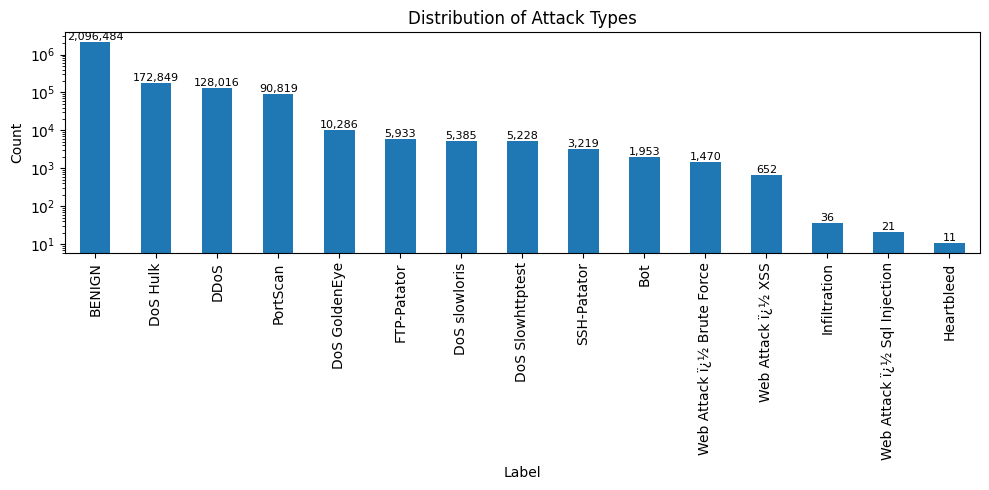

In [78]:
label_counts = df['Label'].value_counts()

plt.figure(figsize=(10, 5))
ax = label_counts.plot(kind='bar')

plt.title("Distribution of Attack Types")
plt.xlabel("Label")
plt.ylabel("Count")

for i, v in enumerate(label_counts):
    ax.text(i, v, f"{v:,}", ha='center', va='bottom', fontsize=8)


plt.yscale('log')

plt.tight_layout()
plt.savefig("../results/label_distribution_bar.png")
plt.show()

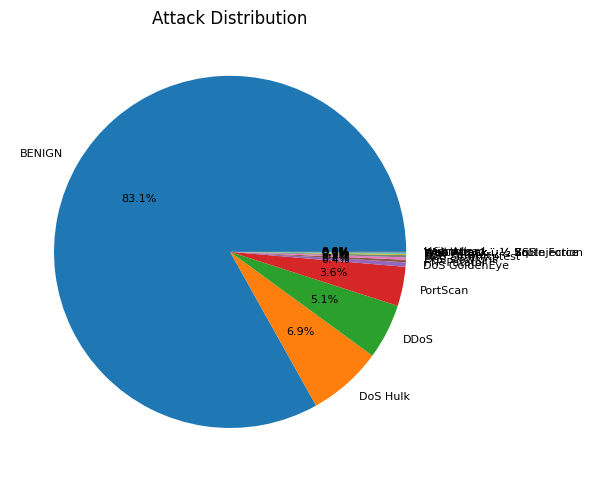

In [79]:
plt.figure(figsize=(6, 6))

label_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    textprops={'fontsize': 8}
)

plt.title("Attack Distribution")
plt.ylabel("")

plt.tight_layout()
plt.savefig("../results/label_distribution_pie.png")
plt.show()

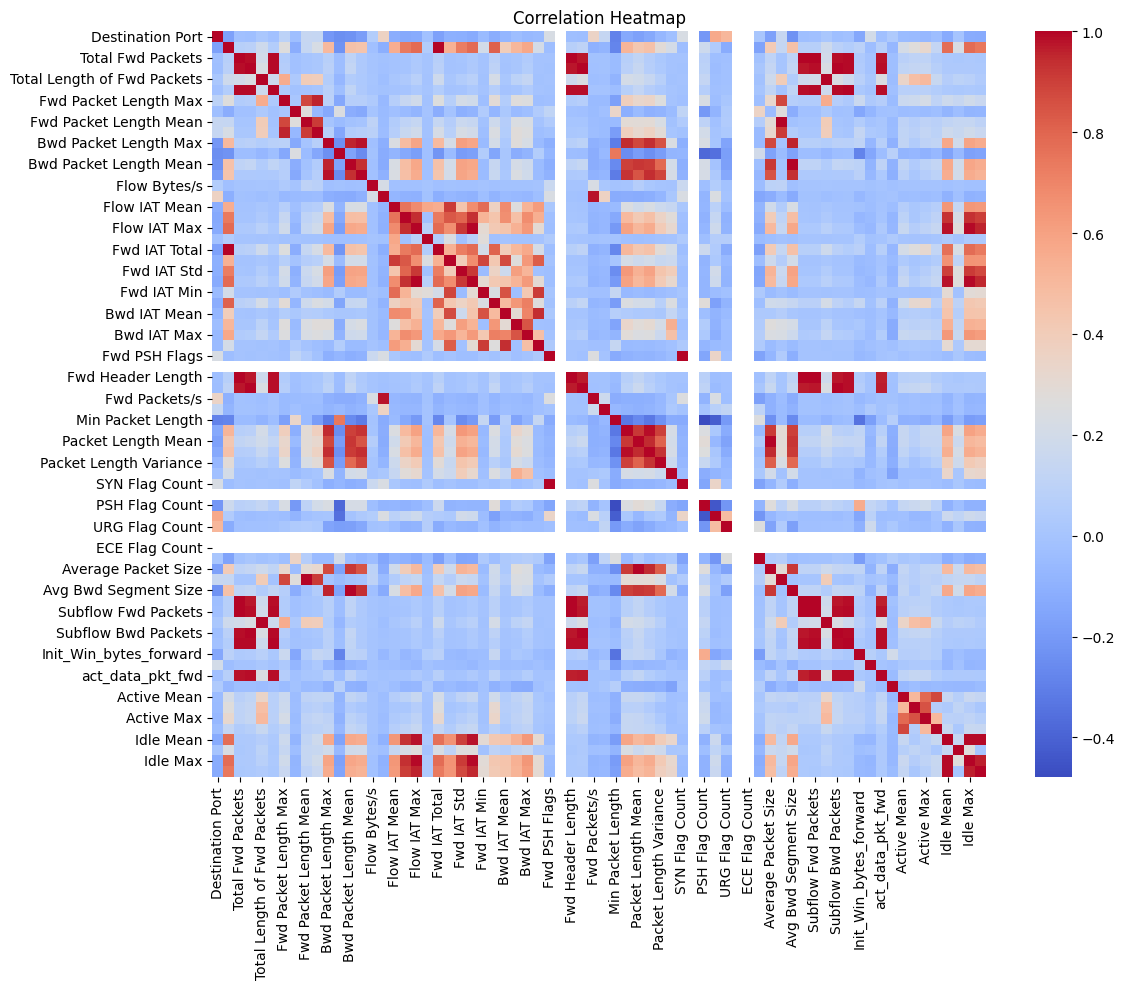

In [80]:
numeric_df = df.select_dtypes(include=[np.number])

sample_df = numeric_df.sample(n=5000, random_state=42)

corr = sample_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("../results/correlation_heatmap.png")
plt.show()

In [81]:
le = LabelEncoder()

df['Label_encoded'] = le.fit_transform(df['Label'])
print(df[['Label', 'Label_encoded']].drop_duplicates())

                               Label  Label_encoded
0                             BENIGN              0
18883                           DDoS              2
1463                        PortScan             10
24072                            Bot              1
66383                   Infiltration              9
12637     Web Attack ï¿½ Brute Force             12
72134             Web Attack ï¿½ XSS             14
90293   Web Attack ï¿½ Sql Injection             13
11347                    FTP-Patator              7
161989                   SSH-Patator             11
6558                   DoS slowloris              6
69275               DoS Slowhttptest              5
74860                       DoS Hulk              4
331033                 DoS GoldenEye              3
597130                    Heartbleed              8


In [82]:
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(label_mapping)

{'BENIGN': np.int64(0), 'Bot': np.int64(1), 'DDoS': np.int64(2), 'DoS GoldenEye': np.int64(3), 'DoS Hulk': np.int64(4), 'DoS Slowhttptest': np.int64(5), 'DoS slowloris': np.int64(6), 'FTP-Patator': np.int64(7), 'Heartbleed': np.int64(8), 'Infiltration': np.int64(9), 'PortScan': np.int64(10), 'SSH-Patator': np.int64(11), 'Web Attack ï¿½ Brute Force': np.int64(12), 'Web Attack ï¿½ Sql Injection': np.int64(13), 'Web Attack ï¿½ XSS': np.int64(14)}


In [83]:
X = df.drop(columns=['Label', 'Label_encoded'])
y = df['Label_encoded']

X.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [84]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Label_encoded, dtype: int64

In [85]:
scaler = StandardScaler()

X[X.select_dtypes(include=[np.number]).columns] = scaler.fit_transform(X[X.select_dtypes(include=[np.number]).columns])
X.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,2.426286,-0.470736,-0.010421,-0.010946,-0.056644,-0.007564,-0.297677,-0.217037,-0.293963,-0.260373,...,-0.007425,0.002697,-0.133328,-0.110847,-0.158407,-0.10708,-0.375644,-0.116044,-0.381002,-0.361637
1,2.436220,-0.470733,-0.011680,-0.010000,-0.057211,-0.007561,-0.297677,-0.217037,-0.293963,-0.260373,...,-0.008908,0.002697,-0.133328,-0.110847,-0.158407,-0.10708,-0.375644,-0.116044,-0.381002,-0.361637
2,2.436273,-0.470735,-0.011680,-0.010000,-0.057211,-0.007561,-0.297677,-0.217037,-0.293963,-0.260373,...,-0.008908,0.002697,-0.133328,-0.110847,-0.158407,-0.10708,-0.375644,-0.116044,-0.381002,-0.361637
3,1.972726,-0.470735,-0.011680,-0.010000,-0.057211,-0.007561,-0.297677,-0.217037,-0.293963,-0.260373,...,-0.008908,0.002697,-0.133328,-0.110847,-0.158407,-0.10708,-0.375644,-0.116044,-0.381002,-0.361637
4,2.426181,-0.470736,-0.010421,-0.010946,-0.056644,-0.007564,-0.297677,-0.217037,-0.293963,-0.260373,...,-0.007425,0.002697,-0.133328,-0.110847,-0.158407,-0.10708,-0.375644,-0.116044,-0.381002,-0.361637


In [86]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [87]:
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

Train set: (2017889, 70), Test set: (504473, 70)


In [88]:
print(f"Label distribution: {y_train.value_counts()}")

Label distribution: Label_encoded
0     1677336
4      137996
2      102518
10      72632
3        8254
7        4773
6        4300
5        4190
11       2586
1        1550
12       1176
14        517
9          32
13         20
8           9
Name: count, dtype: int64


In [89]:
rus = RandomUnderSampler(random_state=42, sampling_strategy={
    0: 250000,

    4: 100000,
    2: 80000,
    10: 60000,

    3: 8000,   
    7: 4000,
    6: 4000,
    5: 4000,

    11: 2000,
    1: 1500,
    12: 1000,
    14: 500,

    9: 32,
    13: 20,
    8: 9
})
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)
print(f"Resampled train set: {X_train_res.shape}, {y_train_res.shape}")


Resampled train set: (515061, 70), (515061,)


In [90]:
smote = SMOTE(
    sampling_strategy={
        3: 20000,
        7: 15000,
        6: 15000,
        5: 15000,
        11: 10000,
        1: 8000,
        12: 6000,
        14: 3000,
        9: 1000,
        13: 1000,
        8: 800
    },
    random_state=42,
    k_neighbors=5
)

X_train_res, y_train_res = smote.fit_resample(X_train_res, y_train_res)

In [91]:
print(f"Resampled train set: {X_train_res.shape}, {y_train_res.shape}")

Resampled train set: (584800, 70), (584800,)


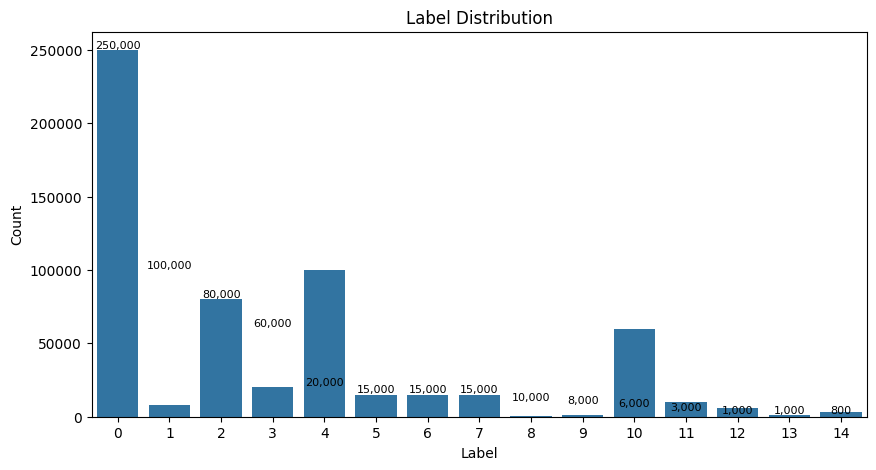

In [92]:
# Label distribution plot of X_train_res, y_train_res
plt.figure(figsize=(10, 5))
sns.countplot(x='Label', data=pd.DataFrame({'Label': y_train_res}))
# attach number each label
for i, v in enumerate(y_train_res.value_counts()):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom', fontsize=8)
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [93]:
X_train_res.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd URG Flags',
       'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s',
       'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length',
       'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
       'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count',

In [94]:
# Không có 'Protocol' -> tạm thời bỏ -> còn 17 features với tên đã sửa
selected_features = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 
    'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 
    'Flow Bytes/s', 'Flow Packets/s', 'Packet Length Mean', 
    'Packet Length Std', 'SYN Flag Count', 'ACK Flag Count', 
    'FIN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'URG Flag Count'
]

X_train_res = X_train_res[selected_features]
X_test = X_test[selected_features]

In [95]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_res, y_train_res)
print("Logistic Regression model trained")

Logistic Regression model trained


In [96]:
# Support Vector Machine
# Đợi train lâu quá -> giảm tập dữ liệu xuống phù hợp hơn
subset_size = 30000 
train_ratio = subset_size / len(X_train_res)

# Lấy mẫu ngẫu nhiên nhưng giữ nguyên tỉ lệ các lớp (stratify)
X_svm_subset, _, y_svm_subset, _ = train_test_split(
    X_train_res, 
    y_train_res, 
    train_size=train_ratio, 
    stratify=y_train_res, 
    random_state=42
)

print(f"Kích thước tập train mới cho SVM: {X_svm_subset.shape}")

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_svm_subset, y_svm_subset)

print("Support Vector Machine model trained on subset!")

Kích thước tập train mới cho SVM: (30000, 17)
Support Vector Machine model trained on subset!


In [97]:
# Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_res, y_train_res)
print("Naive Bayes trained.")

Naive Bayes trained.


In [98]:
# KNN
X_knn_train, _, y_knn_train, _ = train_test_split(  
    X_train_res,
    y_train_res,
    test_size=0.2,
    random_state=42
)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_knn_train, y_knn_train)
print("KNN trained.")

KNN trained.


In [99]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res) 
print("Random Forest trained.")

Random Forest trained.


In [100]:
knn_test_size = 10000 
knn_test_ratio = knn_test_size / len(X_test)

X_knn_test, _, y_knn_test, _ = train_test_split(
    X_test,
    y_test,
    test_size=knn_test_ratio,
    random_state=42
)

models = {
    "Logistic Regression": (lr_model, X_test, y_test),
    "SVM": (svm_model, X_test, y_test),
    "Naive Bayes": (nb_model, X_test, y_test),
    "KNN": (knn_model, X_knn_test, y_knn_test),
    "Random Forest": (rf_model, X_test, y_test)
}

In [101]:
labels = sorted(y_test.unique())
label_names = [str(l) for l in labels]

for name, (model, X_eval, y_eval) in models.items():
    y_pred = model.predict(X_eval)
    print(f"\n{'─' * 60}")
    print(f"  {name}")
    print('─' * 60)
    print(classification_report(y_eval, y_pred, target_names=label_names, zero_division=0))


────────────────────────────────────────────────────────────
  Logistic Regression
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       1.00      0.88      0.94    419148
           1       0.14      0.02      0.04       403
           2       0.56      1.00      0.72     25498
           3       0.45      0.73      0.56      2032
           4       0.89      0.94      0.92     34853
           5       0.19      0.79      0.30      1038
           6       0.43      0.55      0.48      1085
           7       0.10      0.98      0.18      1160
           8       0.10      0.50      0.17         2
           9       0.01      0.25      0.02         4
          10       0.65      1.00      0.79     18187
          11       0.00      0.01      0.01       633
          12       0.74      0.05      0.09       294
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00 

In [102]:
rows = []
for name, (model, X_eval, y_eval) in models.items():
    y_pred = model.predict(X_eval)
    rows.append({
        "Model": name,
        "Accuracy":          accuracy_score(y_eval, y_pred),
        "Macro Precision":   precision_score(y_eval, y_pred, average="macro", zero_division=0),
        "Macro Recall":       recall_score(y_eval, y_pred, average="macro", zero_division=0),
        "Macro F1-score":    f1_score(y_eval, y_pred, average="macro", zero_division=0),
        "Weighted Precision": precision_score(y_eval, y_pred, average="weighted", zero_division=0),
        "Weighted Recall":    recall_score(y_eval, y_pred, average="weighted", zero_division=0),
        "Weighted F1":        f1_score(y_eval, y_pred, average="weighted", zero_division=0),
    })
df_compare = pd.DataFrame(rows).set_index("Model")
print(df_compare.round(4).to_string())

                     Accuracy  Macro Precision  Macro Recall  Macro F1-score  Weighted Precision  Weighted Recall  Weighted F1
Model                                                                                                                         
Logistic Regression    0.8944           0.3510        0.5143          0.3473              0.9446           0.8944       0.9108
SVM                    0.9000           0.3055        0.5520          0.3516              0.9420           0.9000       0.9126
Naive Bayes            0.1548           0.3446        0.5377          0.2505              0.9355           0.1548       0.2024
KNN                    0.9871           0.6470        0.8137          0.6796              0.9935           0.9871       0.9900
Random Forest          0.9907           0.7361        0.8134          0.7522              0.9960           0.9907       0.9932


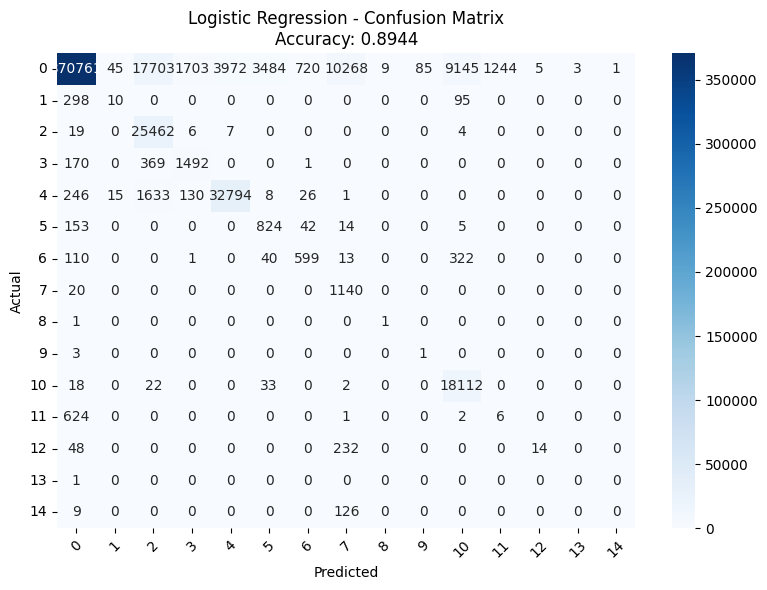

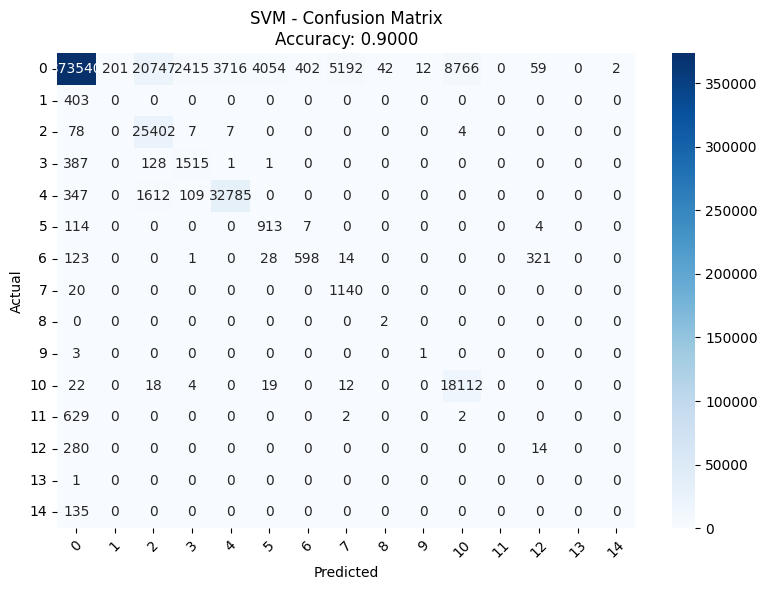

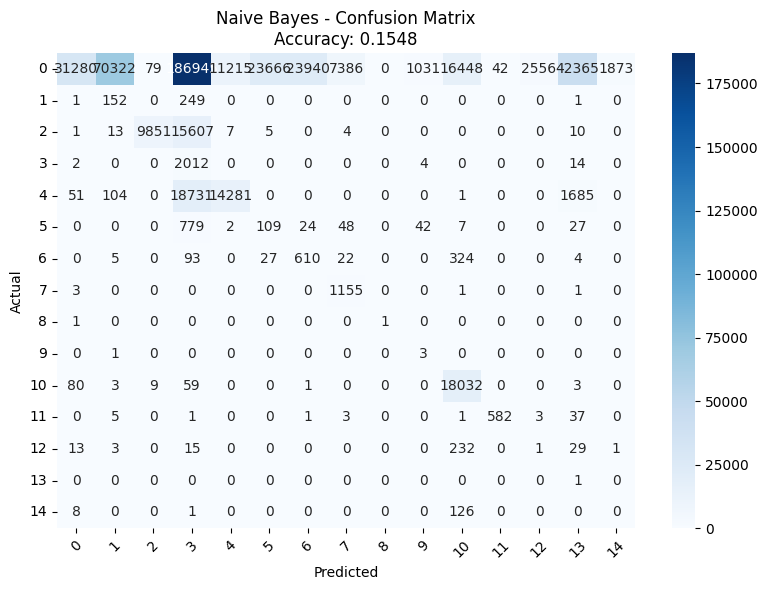

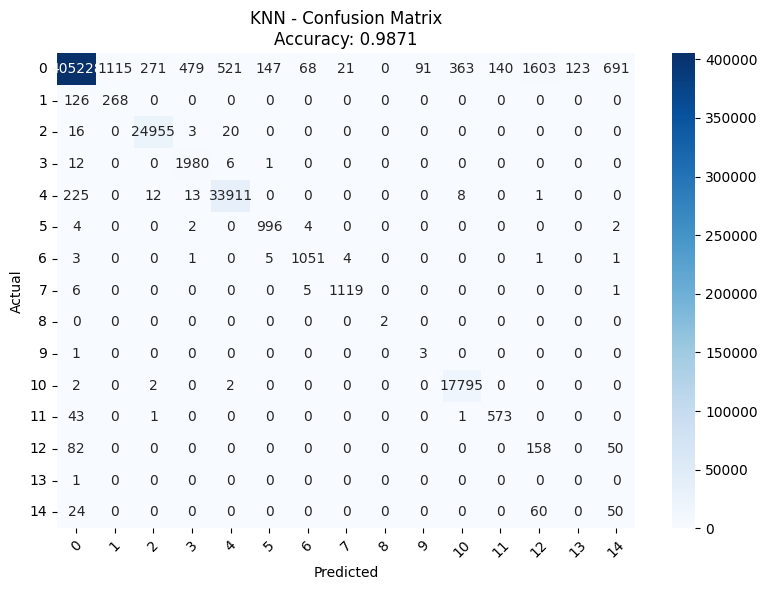

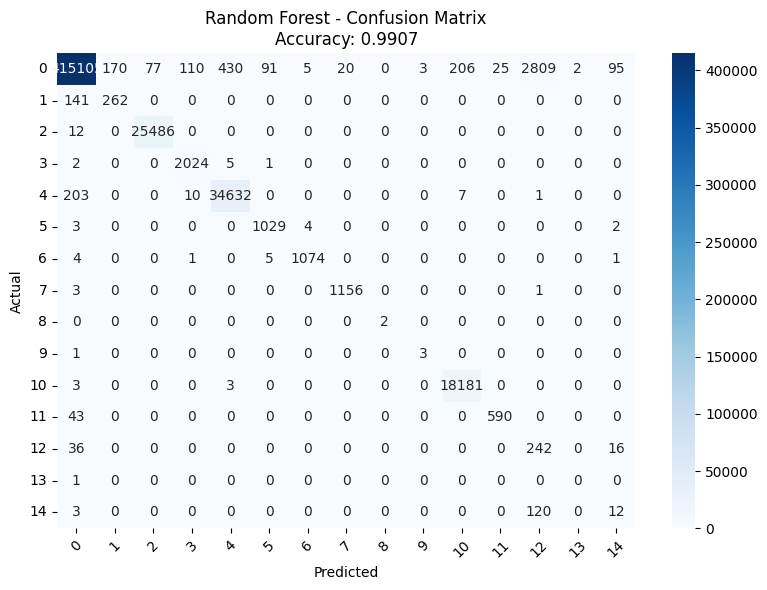

In [103]:
for name, (model, X_eval, y_eval) in models.items():
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_eval, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_names,
        yticklabels=label_names
    )

    acc = accuracy_score(y_eval, y_pred)
    plt.title(f"{name} - Confusion Matrix\nAccuracy: {acc:.4f}", fontsize=12)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

Từ bảng so sánh ở trên -> chọn Random Forest vì : 
  - Accuracy cao nhất  (0.9907)  — sai sót thấp nhất trên tập test
  - Macro F1 cao nhất  (0.7522)  — cân bằng Precision/Recall tốt nhất
  - Weighted F1 cao nhất (0.9932) — hiệu suất tổng thể vượt trội
  - Macro Recall = 0.8134         — bắt được ~81% attack (bỏ sót ít)
  - Không bị overfitting như Naive Bayes, không chậm như SVM

In [104]:
best_model_name = "Random Forest"
best_model, _, _ = models[best_model_name]

save_dir = "../models"
os.makedirs(save_dir, exist_ok=True)

# Lưu model bằng joblib
save_path = os.path.join(save_dir, "random_forest_model.pkl")
joblib.dump(best_model, save_path)

['../models\\random_forest_model.pkl']

In [105]:
# LUU SCALER VA LABEL ENCODER 

scaler_save = StandardScaler()
scaler_save.fit(X)

save_dir = "../models"
os.makedirs(save_dir, exist_ok=True)

joblib.dump(scaler_save, os.path.join(save_dir, "scaler.pkl"))
print(f"[OK] Da luu scaler vao: {save_dir}/scaler.pkl")

joblib.dump(le, os.path.join(save_dir, "label_encoder.pkl"))
print(f"[OK] Da luu LabelEncoder vao: {save_dir}/label_encoder.pkl")

print("\nLabel Mapping (LabelEncoder.classes_):")
for idx, cls in enumerate(le.classes_):
    print(f"  {idx}: {cls}")

[OK] Da luu scaler vao: ../models/scaler.pkl
[OK] Da luu LabelEncoder vao: ../models/label_encoder.pkl

Label Mapping (LabelEncoder.classes_):
  0: BENIGN
  1: Bot
  2: DDoS
  3: DoS GoldenEye
  4: DoS Hulk
  5: DoS Slowhttptest
  6: DoS slowloris
  7: FTP-Patator
  8: Heartbleed
  9: Infiltration
  10: PortScan
  11: SSH-Patator
  12: Web Attack ï¿½ Brute Force
  13: Web Attack ï¿½ Sql Injection
  14: Web Attack ï¿½ XSS
